# Notebook 1 v3 - Full Dataset Intake Profiling and Representative Sampling Check

This notebook profiles the full NYC 311 parquet file without loading all 20M records into memory.

1. Uses parquet metadata and row group scanning instead of loading the full file.
2. Creates a small representative sample by reading across row groups, not just the first rows.
3. Saves a manifest that downstream notebooks use to avoid path confusion.
4. Produces report-ready profiling outputs for missingness, schema, date coverage, and top categorical values.

This notebook is intentionally descriptive. Modeling starts in Notebook 3.


In [ ]:
import os
import gc
import json
import math
import time
import shutil
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Optional install check for pyarrow.
try:
    import pyarrow.parquet as pq
except Exception:
    !pip -q install pyarrow
    import pyarrow.parquet as pq


In [ ]:
# USER CONFIGURATION

# Update this to the full NYC 311 parquet file in Google Drive or Colab.
# SOURCE_PARQUET = "/content/drive/MyDrive/project_data/Capstone Course Project Files/Data/nyc_311_FINAL_UPDATED.parquet"
SOURCE_PARQUET = "/content/drive/MyDrive/project_data/Capstone Course Project Files/Data/enriched_cleaned_nyc_311.parquet"

# Output folder for Notebook 1 artifacts.
OUTPUT_DIR = Path("/content/notebook1_v3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Number of rows for a lightweight development/profile sample.
# This is not the modeling sample. Notebook 2 creates the modeling sample.
PROFILE_SAMPLE_TARGET_ROWS = 300_000

# Columns worth profiling more deeply if they exist.
KEY_CATEGORICAL_COLUMNS = [
    "complaint_type", "agency", "borough", "status", "location_type",
    "city", "incident_zip", "open_data_channel_type", "descriptor"
]
KEY_DATETIME_COLUMNS = ["created_date", "closed_date", "due_date", "resolution_action_updated_date"]
KEY_NUMERIC_COLUMNS = ["latitude", "longitude"]

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Run timestamp:", RUN_TS)
print("Output directory:", OUTPUT_DIR)


Run timestamp: 20260512_094829
Output directory: /content/notebook1_v3_outputs


In [ ]:
# GOOGLE DRIVE MOUNT
# Run this cell in Colab if the parquet is stored in Google Drive.

if SOURCE_PARQUET.startswith("/content/drive"):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print("Drive mount skipped or not running in Colab:", e)


Mounted at /content/drive


In [ ]:
# VALIDATE SOURCE AND READ PARQUET METADATA

if not os.path.exists(SOURCE_PARQUET):
    raise FileNotFoundError(
        f"SOURCE_PARQUET was not found: {SOURCE_PARQUET}\n"
        "Update SOURCE_PARQUET in the configuration cell before running."
    )

pf = pq.ParquetFile(SOURCE_PARQUET)
metadata = pf.metadata
schema_names = pf.schema_arrow.names

parquet_summary = {
    "source_parquet": SOURCE_PARQUET,
    "num_rows": metadata.num_rows,
    "num_columns": len(schema_names),
    "num_row_groups": metadata.num_row_groups,
    "created_at": RUN_TS,
}

print(json.dumps(parquet_summary, indent=2))
pd.DataFrame([parquet_summary]).to_csv(OUTPUT_DIR / "parquet_inventory.csv", index=False)
pd.DataFrame({"column_name": schema_names}).to_csv(OUTPUT_DIR / "schema_columns.csv", index=False)


{
  "source_parquet": "/content/drive/MyDrive/project_data/Capstone Course Project Files/Data/enriched_cleaned_nyc_311.parquet",
  "num_rows": 20448149,
  "num_columns": 48,
  "num_row_groups": 20,
  "created_at": "20260512_094829"
}


In [ ]:
# HELPER FUNCTIONS
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names to snake_case for consistent downstream processing."""
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(r"[^0-9a-zA-Z_]+", "", regex=True)
    )
    return df


def existing_columns(columns):
    """Return only columns that exist in the source parquet."""
    original_lower = {c.lower().replace(' ', '_').replace('-', '_').replace('/', '_'): c for c in schema_names}
    found = []
    for c in columns:
        key = c.lower().replace(' ', '_').replace('-', '_').replace('/', '_')
        if key in original_lower:
            found.append(original_lower[key])
        elif c in schema_names:
            found.append(c)
    return list(dict.fromkeys(found))


def read_row_group_sample(pf, target_rows=100_000, columns=None, random_state=42):
    """Create a representative sample by taking rows from every row group.

    This avoids the old problem of reading only the first rows from a date-sorted parquet.
    """
    rng = np.random.default_rng(random_state)
    n_groups = pf.metadata.num_row_groups
    rows_per_group = max(1, math.ceil(target_rows / n_groups))
    pieces = []
    for rg in range(n_groups):
        table = pf.read_row_group(rg, columns=columns)
        df = table.to_pandas()
        if len(df) > rows_per_group:
            df = df.sample(n=rows_per_group, random_state=int(rng.integers(0, 1_000_000)))
        pieces.append(df)
        if rg % 10 == 0:
            print(f"Sampled row group {rg+1}/{n_groups}")
    out = pd.concat(pieces, ignore_index=True)
    if len(out) > target_rows:
        out = out.sample(n=target_rows, random_state=random_state).reset_index(drop=True)
    return normalize_columns(out)


In [ ]:
import time

# FULL DATASET NULL SCAN BY ROW GROUP
# This scans the full dataset in row groups but only stores aggregate counts.

null_counts = None
row_count = 0
start = time.time()

for rg in range(pf.metadata.num_row_groups):
    retries = 3
    for attempt in range(retries):
        try:
            df = pf.read_row_group(rg).to_pandas()
            break  # Success, break out of retry loop
        except OSError as e:
            if attempt < retries - 1:
                print(f"Error reading row group {rg}. Retrying in 5 seconds... ({attempt+1}/{retries})")
                time.sleep(5)
            else:
                print(f"Failed to read row group {rg} after {retries} attempts.")
                raise  # Re-raise the exception if all retries fail

    df = normalize_columns(df)
    row_count += len(df)
    cur = df.isna().sum()
    null_counts = cur if null_counts is None else null_counts.add(cur, fill_value=0)
    del df
    gc.collect()
    if rg % 10 == 0:
        print(f"Processed row group {rg+1}/{pf.metadata.num_row_groups}. Rows scanned: {row_count:,}")

profile = pd.DataFrame({
    "column_name": null_counts.index,
    "missing_count": null_counts.values.astype(int),
    "missing_pct": (null_counts.values / row_count) * 100,
    "total_rows_scanned": row_count,
}).sort_values("missing_pct", ascending=False)

profile.to_csv(OUTPUT_DIR / "full_dataset_missingness_profile.csv", index=False)
display(profile.head(20))
print(f"Full null scan completed in {(time.time()-start)/60:.1f} minutes")

Processed row group 1/20. Rows scanned: 1,048,576
Processed row group 11/20. Rows scanned: 11,534,336


,column_name,missing_count,missing_pct,total_rows_scanned
17,park_facility_name,20448147,99.999990,20448149
18,landmark,20448147,99.999990,20448149
16,bridge_highway_name,20448147,99.999990,20448149
37,household_inc,4866437,23.798912,20448149
35,not_citizen_pct,4855144,23.743685,20448149
32,white_pct,4855144,23.743685,20448149
34,hispanic_pct,4855144,23.743685,20448149
33,black_pct,4855144,23.743685,20448149
36,below_poverty_pct,4855144,23.743685,20448149
1,address_type,2656566,12.991719,20448149


Full null scan completed in 0.6 minutes


In [ ]:
# REPRESENTATIVE PROFILE SAMPLE
# Read only important columns plus schema-safe detected fields for profiling.

profile_columns = existing_columns(KEY_CATEGORICAL_COLUMNS + KEY_DATETIME_COLUMNS + KEY_NUMERIC_COLUMNS)
print("Columns selected for profile sample:", profile_columns)

profile_sample = read_row_group_sample(
    pf,
    target_rows=PROFILE_SAMPLE_TARGET_ROWS,
    columns=profile_columns if profile_columns else None,
    random_state=42,
)

profile_sample.to_parquet(OUTPUT_DIR / "profile_sample_representative.parquet", index=False)
profile_sample.head()


Columns selected for profile sample: ['complaint_type', 'borough', 'location_type', 'open_data_channel_type', 'descriptor', 'created_date', 'closed_date', 'latitude', 'longitude']
Sampled row group 1/20
Sampled row group 11/20


,complaint_type,borough,location_type,open_data_channel_type,descriptor,created_date,closed_date,latitude,longitude
0,ELECTRIC,BRONX,RESIDENTIAL BUILDING,PHONE,LIGHTING,2026-03-18 18:56:08,NaT,40.883980,-73.866196
1,Encampment,MANHATTAN,Street/Sidewalk,MOBILE,NaN,2025-11-19 15:40:41,2025-11-20 14:39:29,40.731456,-73.985578
2,Noise,QUEENS,NaN,ONLINE,Noise: Alarms (NR3),2025-11-14 18:47:00,2025-11-19 00:42:00,40.750166,-73.940947
3,Derelict Vehicles,QUEENS,Street,PHONE,Derelict Vehicles,2025-11-19 12:50:00,2025-11-20 04:14:00,40.721762,-73.908806
4,Graffiti,BROOKLYN,Mixed Use,UNKNOWN,Graffiti,2025-12-10 14:22:15,NaT,40.597549,-73.985409


In [ ]:
# DATE COVERAGE AND TOP VALUE TABLES

# Date coverage tables
for c in [x for x in KEY_DATETIME_COLUMNS if x in profile_sample.columns]:
    dt = pd.to_datetime(profile_sample[c], errors="coerce")
    date_summary = pd.DataFrame({
        "column": [c],
        "min_date": [dt.min()],
        "max_date": [dt.max()],
        "missing_count": [dt.isna().sum()],
        "missing_rate": [dt.isna().mean()]
    })
    date_summary.to_csv(OUTPUT_DIR / f"date_coverage_{c}.csv", index=False)

# Top categorical value tables
for c in [x for x in KEY_CATEGORICAL_COLUMNS if x in profile_sample.columns]:
    top = (
        profile_sample[c]
        .astype("object")
        .where(profile_sample[c].notna(), "UNKNOWN")
        .astype(str)
        .value_counts()
        .head(25)
        .reset_index()
    )

    top.columns = [c, "sample_count"]
    top.to_csv(OUTPUT_DIR / f"top_values_{c}.csv", index=False)

print("Saved date coverage and top value tables to:", OUTPUT_DIR)

Saved date coverage and top value tables to: /content/notebook1_v3_outputs


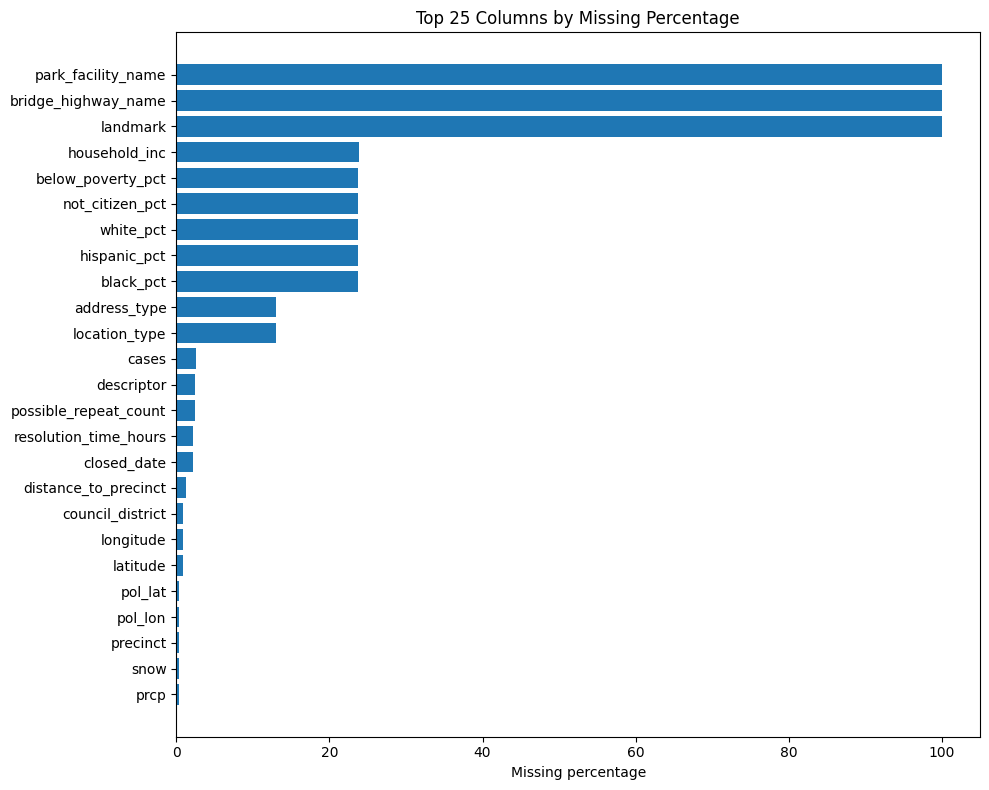

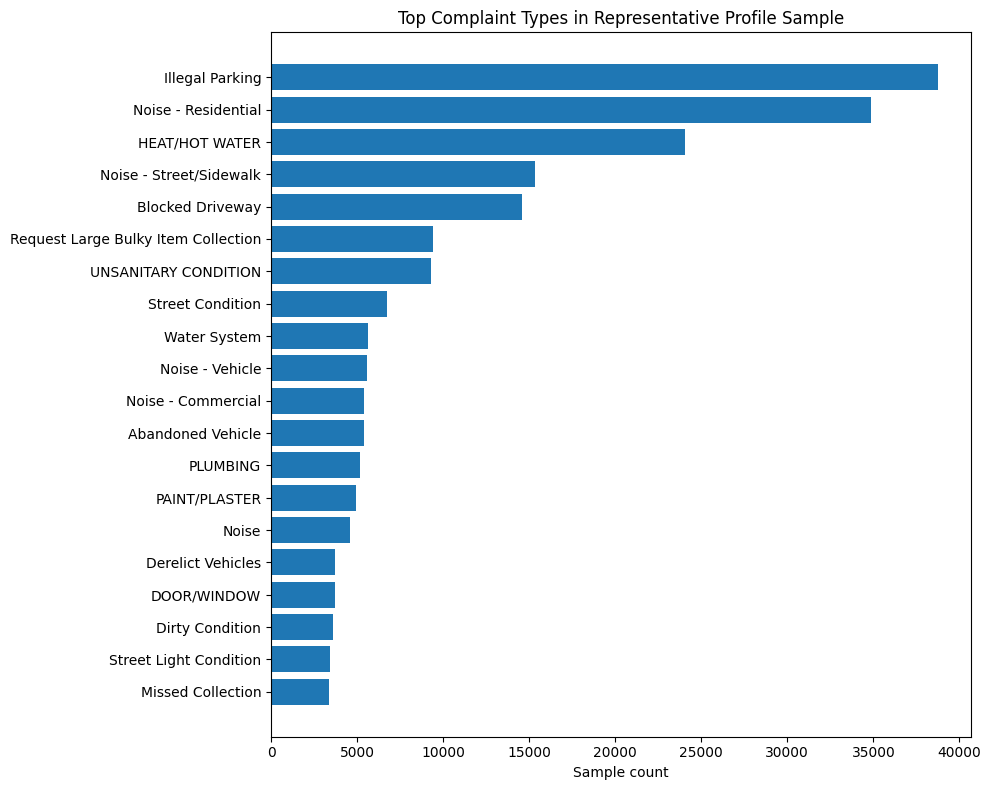

Saved basic profile plots to: /content/notebook1_v3_outputs/plots


In [ ]:
# BASIC PROFILE PLOTS

plot_dir = OUTPUT_DIR / "plots"
plot_dir.mkdir(exist_ok=True)

# Missingness plot
plot_data = profile.head(25).sort_values("missing_pct")

plt.figure(figsize=(10, 8))
plt.barh(plot_data["column_name"], plot_data["missing_pct"])
plt.title("Top 25 Columns by Missing Percentage")
plt.xlabel("Missing percentage")
plt.tight_layout()
plt.savefig(plot_dir / "missingness_top25.png", dpi=160)
plt.show()

# Top complaint type plot if available
# NOTE:
# Some parquet columns may load as pandas Categorical dtype.
# We convert to object before replacing missing values so pandas does not
# raise a "new category UNKNOWN" error.
if "complaint_type" in profile_sample.columns:
    complaint_series = (
        profile_sample["complaint_type"]
        .astype("object")
        .where(profile_sample["complaint_type"].notna(), "UNKNOWN")
        .astype(str)
    )

    vc = complaint_series.value_counts().head(20).sort_values()

    plt.figure(figsize=(10, 8))
    plt.barh(vc.index, vc.values)
    plt.title("Top Complaint Types in Representative Profile Sample")
    plt.xlabel("Sample count")
    plt.tight_layout()
    plt.savefig(plot_dir / "top_complaint_types_profile_sample.png", dpi=160)
    plt.show()

print("Saved basic profile plots to:", plot_dir)

In [ ]:
# SAVE MANIFEST FOR NOTEBOOK 2

manifest = {
    "run_timestamp": RUN_TS,
    "source_parquet": SOURCE_PARQUET,
    "output_dir": str(OUTPUT_DIR),
    "num_rows": int(metadata.num_rows),
    "num_columns": int(len(schema_names)),
    "num_row_groups": int(metadata.num_row_groups),
    "profile_sample_path": str(OUTPUT_DIR / "profile_sample_representative.parquet"),
    "missingness_profile_path": str(OUTPUT_DIR / "full_dataset_missingness_profile.csv"),
    "important_note": "Notebook 1 v3 scans the full parquet by row group and creates a representative sample across row groups. It does not use first-N-row sampling.",
}

with open(OUTPUT_DIR / "run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

# Also copy to /content for easy handoff in Colab.
shutil.copy(OUTPUT_DIR / "run_manifest.json", "/content/run_manifest.json")
print(json.dumps(manifest, indent=2))


{
  "run_timestamp": "20260512_094829",
  "source_parquet": "/content/drive/MyDrive/project_data/Capstone Course Project Files/Data/enriched_cleaned_nyc_311.parquet",
  "output_dir": "/content/notebook1_v3_outputs",
  "num_rows": 20448149,
  "num_columns": 48,
  "num_row_groups": 20,
  "profile_sample_path": "/content/notebook1_v3_outputs/profile_sample_representative.parquet",
  "missingness_profile_path": "/content/notebook1_v3_outputs/full_dataset_missingness_profile.csv",
  "important_note": "Notebook 1 v3 scans the full parquet by row group and creates a representative sample across row groups. It does not use first-N-row sampling."
}


In [ ]:
# ZIP OUTPUTS FOR DOWNLOAD

zip_path = "/content/notebook1_v3_outputs.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive(zip_path.replace(".zip", ""), "zip", OUTPUT_DIR)
print("Created:", zip_path)


Created: /content/notebook1_v3_outputs.zip
